In [6]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [7]:
def pdf(x, mu, sigma, n):
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

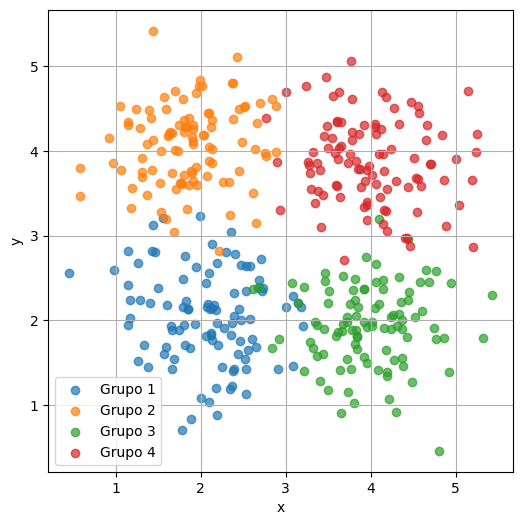

In [8]:
nc = 100
dimension = 2
std = 0.5

g1 = std*np.random.randn(nc, dimension) + np.array([2,2])
g2 = std*np.random.randn(nc, dimension) + np.array([2,4])
g3 = std*np.random.randn(nc, dimension) + np.array([4,2])
g4 = std*np.random.randn(nc, dimension) + np.array([4,4])

plt.figure(figsize=(6,6))
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
k1 = np.cov(g1.T)
k2 = np.cov(g2.T)
k3 = np.cov(g3.T)
k4 = np.cov(g4.T)

m1 = np.mean(g1, axis = 0)
m2 = np.mean(g2, axis = 0)
m3 = np.mean(g3, axis = 0)
m4 = np.mean(g4, axis = 0)


seqi = np.arange(0,6,0.1)
seqj = np.arange(0,6,0.1)

M = np.zeros(shape = (len(seqi),len(seqj)))

N1 = len(g1)
N2 = len(g2)
N3 = len(g3)
N4 = len(g4)

Nall = N1+N2+N3+N4

p1 = N1/Nall
p2 = N2/Nall
p3 = N3/Nall
p4 = N4/Nall

for ii, i in enumerate(seqi):       
    for jj, j in enumerate(seqj):  
        x = np.array([i, j])
        M[ii, jj] = (
            p1*pdf(x, m1, k1, dimension) +
            p2*pdf(x, m2, k2, dimension) +
            p3*pdf(x, m3, k3, dimension) +
            p4*pdf(x, m4, k4, dimension)
        )

/tmp/ipykernel_2292/4139100668.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(const * np.exp(expo))


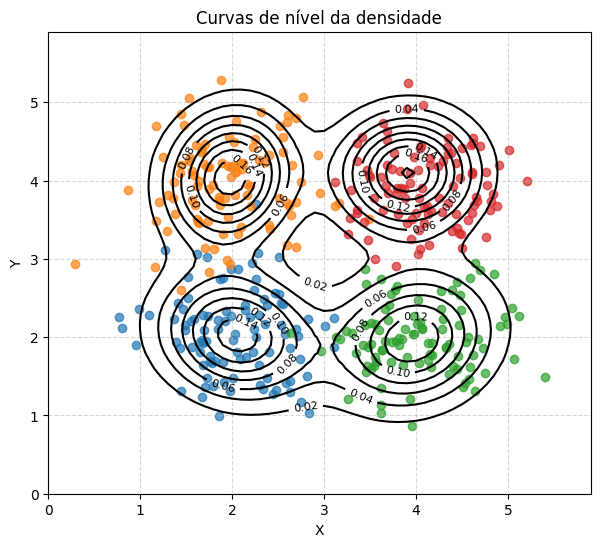

In [6]:
X, Y = np.meshgrid(seqi, seqj)
plt.figure(figsize=(7,6))
cs = plt.contour(X, Y, M, levels=10, colors="black")  
plt.clabel(cs, inline=True, fontsize=8) 
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)
plt.title("Curvas de nível da densidade")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [7]:
fig = go.Figure(data=[go.Surface(z=M, x=X, y=Y, colorscale="Viridis")])
fig.update_layout(
    title="Densidade da mistura Gaussiana",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Densidade"
    )
)
fig.show() 

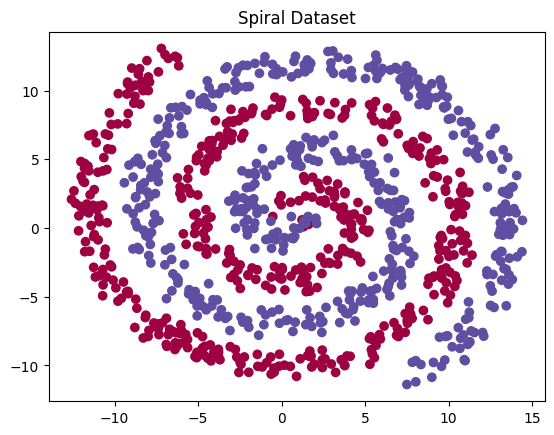

In [12]:
def generate_spiral(n_points, noise=0.5):
    n = np.sqrt(np.random.rand(n_points)) * 780 * (2 * np.pi) / 360
    d1x = -np.cos(n) * n + np.random.rand(n_points) * noise
    d1y = np.sin(n) * n + np.random.rand(n_points) * noise

    d2x = np.cos(n) * n + np.random.rand(n_points) * noise
    d2y = -np.sin(n) * n + np.random.rand(n_points) * noise

    X = np.concatenate((np.vstack((d1x, d1y)).T, np.vstack((d2x, d2y)).T))
    y = np.concatenate((np.zeros(n_points), np.ones(n_points)))

    return X, y

X, y = generate_spiral(500, noise=2)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.title("Spiral Dataset")
plt.show()


In [13]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None

    def fit(self, X):
        if self.random_state:
            np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)

            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.n_clusters)])

            shift = np.linalg.norm(self.centroids - new_centroids)
            if shift < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels
        return self

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign_clusters(X)

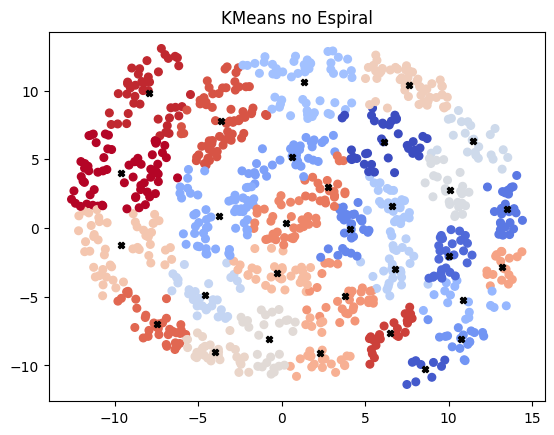

In [15]:
kmeans = KMeans(n_clusters=30, random_state=42)
kmeans.fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="coolwarm", s=30)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c="black", marker="X", s=20)
plt.title("KMeans no Espiral")
plt.show()


In [18]:
n_clusters = 30
n_features = X.shape[1]
n_samples = X.shape[0]

mus = []
sigmas = []
pis = []

for k in range(n_clusters):
    cluster_data = X[kmeans.labels_ == k]
    mu_k = cluster_data.mean(axis=0)
    sigma_k = np.cov(cluster_data, rowvar=False) + 1e-6*np.eye(n_features)  
    pi_k = cluster_data.shape[0] / n_samples
    
    mus.append(mu_k)
    sigmas.append(sigma_k)
    pis.append(pi_k)

mus = np.array(mus)
sigmas = np.array(sigmas)
pis = np.array(pis)


In [20]:
import plotly.graph_objects as go

x = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
X_grid, Y_grid = np.meshgrid(x, y)
Z = np.zeros_like(X_grid)

def gmm_density(x, y, mus, sigmas, pis):
    point = np.array([x, y])
    total = 0
    n_features = 2
    for k in range(len(pis)):
        total += pis[k] * pdf(point, mus[k], sigmas[k], n_features)
    return total

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        Z[i, j] = gmm_density(X_grid[i, j], Y_grid[i, j], mus, sigmas, pis)

surface = go.Surface(x=X_grid, y=Y_grid, z=Z, colorscale='Viridis', opacity=0.7, name='GMM Density')

scatter_data = go.Scatter3d(
    x=X[:,0],
    y=X[:,1],
    z=np.zeros_like(X[:,0]),
    mode='markers',
    marker=dict(size=4, color='red'),
    name='Dados'
)

scatter_centers = go.Scatter3d(
    x=mus[:,0],
    y=mus[:,1],
    z=np.zeros_like(mus[:,0]),
    mode='markers',
    marker=dict(size=8, color='black', symbol='x'),
    name='Centros GMM'
)

fig = go.Figure(data=[surface, scatter_data, scatter_centers])
fig.update_layout(scene=dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Densidade'),
                  title='Superfície de densidade GMM após KMeans')

fig.show()


/tmp/ipykernel_1304/4139100668.py:5: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [36]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture

X, y = generate_spiral(500, noise=2)

def select_best_gmm(X_train, max_components=10):
    best_gmm = None
    best_bic = np.inf
    best_k = 0
    
    for k in range(1, max_components+1):
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_k = k
    
    return best_gmm, best_k, best_bic

split_options = range(2, 35)
results = []

for n_splits in split_options:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    log_likelihoods = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        best_gmm, best_k, best_bic = select_best_gmm(X_train, max_components=10)
        ll = best_gmm.score(X_test) * len(X_test)
        log_likelihoods.append(ll)
    
    mean_ll = np.mean(log_likelihoods)
    std_ll = np.std(log_likelihoods)
    results.append((n_splits, mean_ll, std_ll))
    print(f"n_splits={n_splits} | Log-verossimilhança média={mean_ll:.2f} | Desvio padrão={std_ll:.2f}")


best_split = max(results, key=lambda x: x[1])
print(f"\nMelhor n_splits: {best_split[0]} com log-verossimilhança média = {best_split[1]:.2f}")


n_splits=2 | Log-verossimilhança média=-3282.56 | Desvio padrão=20.42
n_splits=3 | Log-verossimilhança média=-2175.63 | Desvio padrão=4.74
n_splits=4 | Log-verossimilhança média=-1629.68 | Desvio padrão=4.39
n_splits=5 | Log-verossimilhança média=-1303.36 | Desvio padrão=3.53
n_splits=6 | Log-verossimilhança média=-1084.04 | Desvio padrão=2.90
n_splits=7 | Log-verossimilhança média=-930.96 | Desvio padrão=6.03
n_splits=8 | Log-verossimilhança média=-814.33 | Desvio padrão=3.15
n_splits=9 | Log-verossimilhança média=-723.74 | Desvio padrão=2.66
n_splits=10 | Log-verossimilhança média=-651.55 | Desvio padrão=2.50
n_splits=11 | Log-verossimilhança média=-591.39 | Desvio padrão=3.41
n_splits=12 | Log-verossimilhança média=-541.89 | Desvio padrão=4.11
n_splits=13 | Log-verossimilhança média=-500.12 | Desvio padrão=2.51
n_splits=14 | Log-verossimilhança média=-464.62 | Desvio padrão=3.93
n_splits=15 | Log-verossimilhança média=-433.97 | Desvio padrão=2.99
n_splits=16 | Log-verossimilhança mé

Fold 1 | Acurácia = 0.8900
Fold 2 | Acurácia = 0.9100
Fold 3 | Acurácia = 0.8800
Fold 4 | Acurácia = 0.8900
Fold 5 | Acurácia = 0.8900
Fold 6 | Acurácia = 0.9200
Fold 7 | Acurácia = 0.8500
Fold 8 | Acurácia = 0.8900
Fold 9 | Acurácia = 0.8700
Fold 10 | Acurácia = 0.8300

=== Resultados ===
Acurácia média: 0.8820
Desvio padrão: 0.0252
Melhor fold: 6 | Acurácia = 0.9200


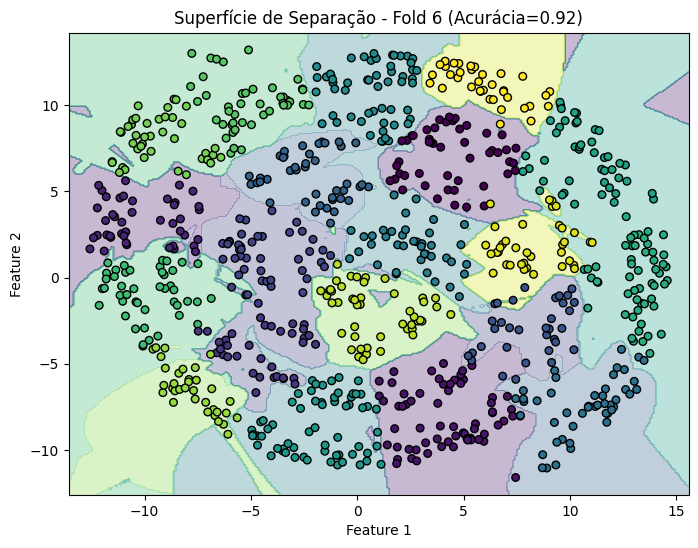

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

n_splits = 10
n_components = 10
random_state = 42
n_clusters = 20  

kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

accuracies = []
models = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    y_train = kmeans.fit_predict(X_train)
    
    y_test = kmeans.predict(X_test)
    
    classes = np.unique(y_train)
    gmms = {}
    priors = {}

    for c in classes:
        Xc = X_train[y_train == c]
        k_comp = min(n_components, max(1, Xc.shape[0]))
        gmm = GaussianMixture(n_components=k_comp, covariance_type='full', random_state=random_state)
        gmm.fit(Xc)
        gmms[c] = gmm
        priors[c] = Xc.shape[0] / X_train.shape[0]
    
    log_priors = {c: np.log(priors[c]) for c in classes}
    
    y_pred = []
    for x in X_test:
        scores = {c: gmms[c].score_samples(x.reshape(1, -1))[0] + log_priors[c] for c in classes}
        y_pred.append(max(scores, key=scores.get))
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    models.append((gmms, log_priors, X_train, y_train))
    
    print(f"Fold {fold} | Acurácia = {acc:.4f}")

mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
best_fold = np.argmax(accuracies)
best_acc = accuracies[best_fold]
best_model, _, X_train_best, y_train_best = models[best_fold]

print("\n=== Resultados ===")
print(f"Acurácia média: {mean_acc:.4f}")
print(f"Desvio padrão: {std_acc:.4f}")
print(f"Melhor fold: {best_fold+1} | Acurácia = {best_acc:.4f}")

# Plot da superfície de separação
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = []
for point in np.c_[xx.ravel(), yy.ravel()]:
    scores = {c: best_model[c].score_samples([point])[0] for c in best_model}
    Z.append(max(scores, key=scores.get))
Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_best[:, 0], X_train_best[:, 1], c=y_train_best, s=30, edgecolor='k')
plt.title(f"Superfície de Separação - Fold {best_fold+1} (Acurácia={best_acc:.2f})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# Parâmetros
n_splits = 10
max_components = 30  # Máximo de gaussianas por cluster
random_state = 42
n_clusters_init = 10  # Número inicial de clusters para KMeans

kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

accuracies = []
models = []

def select_best_gmm(Xc, max_components=10):
    """Seleciona o melhor GMM para os dados Xc baseado no BIC"""
    best_bic = np.inf
    best_gmm = None
    for k in range(1, min(max_components, Xc.shape[0]) + 1):
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        gmm.fit(Xc)
        bic = gmm.bic(Xc)
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
    return best_gmm, best_gmm.n_components

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]

    # 1️⃣ KMeans inicial
    kmeans = KMeans(n_clusters=n_clusters_init, random_state=random_state)
    y_train_init = kmeans.fit_predict(X_train)
    
    # 2️⃣ Ajuste GMM em cada cluster para determinar número ótimo de gaussianas
    optimal_components = []
    for c in np.unique(y_train_init):
        Xc = X_train[y_train_init == c]
        _, n_gauss = select_best_gmm(Xc, max_components=max_components)
        optimal_components.append(n_gauss)
    
    # 3️⃣ Novo número de clusters
    n_clusters_new = sum(optimal_components)
    print(f"Fold {fold}: Número de clusters redefinido = {n_clusters_new}")

    # 4️⃣ KMeans final com novo número de clusters
    kmeans = KMeans(n_clusters=n_clusters_new, random_state=random_state)
    y_train = kmeans.fit_predict(X_train)
    y_test = kmeans.predict(X_test)

    # 5️⃣ Ajuste GMM final por cluster
    classes = np.unique(y_train)
    gmms_final = {}
    priors_final = {}
    for c in classes:
        Xc = X_train[y_train == c]
        gmm, _ = select_best_gmm(Xc, max_components=max_components)
        gmms_final[c] = gmm
        priors_final[c] = Xc.shape[0] / X_train.shape[0]
    
    log_priors = {c: np.log(priors_final[c]) for c in classes}

    # 6️⃣ Predição e acurácia
    y_pred = []
    for x in X_test:
        scores = {c: gmms_final[c].score_samples(x.reshape(1, -1))[0] + log_priors[c] for c in classes}
        y_pred.append(max(scores, key=scores.get))
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    models.append((gmms_final, log_priors, X_train, y_train))
    
    print(f"Fold {fold} | Acurácia = {acc:.4f}")

# ✅ Resultados gerais
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
best_fold = np.argmax(accuracies)
best_acc = accuracies[best_fold]
best_model, _, X_train_best, y_train_best = models[best_fold]

print("\n=== Resultados ===")
print(f"Acurácia média: {mean_acc:.4f}")
print(f"Desvio padrão: {std_acc:.4f}")
print(f"Melhor fold: {best_fold+1} | Acurácia = {best_acc:.4f}")

# 7️⃣ Plot da superfície de separação
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = []
for point in np.c_[xx.ravel(), yy.ravel()]:
    scores = {c: best_model[c].score_samples([point])[0] for c in best_model}
    Z.append(max(scores, key=scores.get))
Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_best[:, 0], X_train_best[:, 1], c=y_train_best, s=30, edgecolor='k')
plt.title(f"Superfície de Separação - Fold {best_fold+1} (Acurácia={best_acc:.2f})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



Fold 1: Número de clusters redefinido = 34
Fold 1 | Acurácia = 0.3100
Fold 2: Número de clusters redefinido = 29
Fold 2 | Acurácia = 0.4000
Fold 3: Número de clusters redefinido = 31
Fold 3 | Acurácia = 0.3900
Fold 4: Número de clusters redefinido = 27
Fold 4 | Acurácia = 0.4300
Fold 5: Número de clusters redefinido = 34
Fold 5 | Acurácia = 0.3500
Fold 6: Número de clusters redefinido = 29
Fold 6 | Acurácia = 0.4200
Fold 7: Número de clusters redefinido = 25
Fold 7 | Acurácia = 0.4300
Fold 8: Número de clusters redefinido = 26
Fold 8 | Acurácia = 0.2400
Fold 9: Número de clusters redefinido = 27
Fold 9 | Acurácia = 0.3600
Fold 10: Número de clusters redefinido = 29
Fold 10 | Acurácia = 0.3200

=== Resultados ===
Acurácia média: 0.3650
Desvio padrão: 0.0585
Melhor fold: 4 | Acurácia = 0.4300


KeyboardInterrupt: 